In [1]:
from pathlib import Path
import cv2
import numpy as np
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

## notebook/passport.jpg

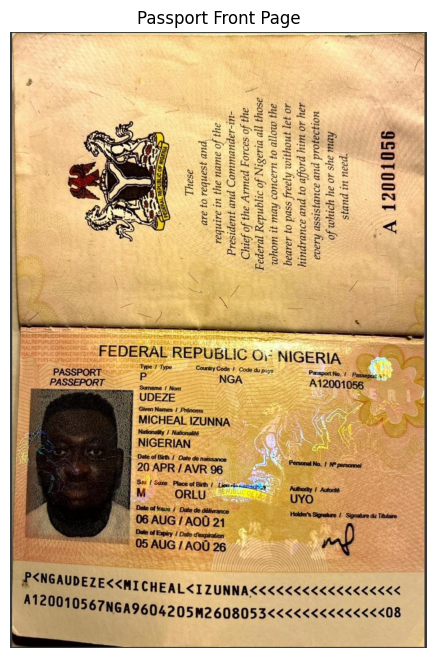

In [3]:
image_path = Path("passport.jpg")  # or your local notebook path
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Passport Front Page")
plt.show()

## Enlarging the image

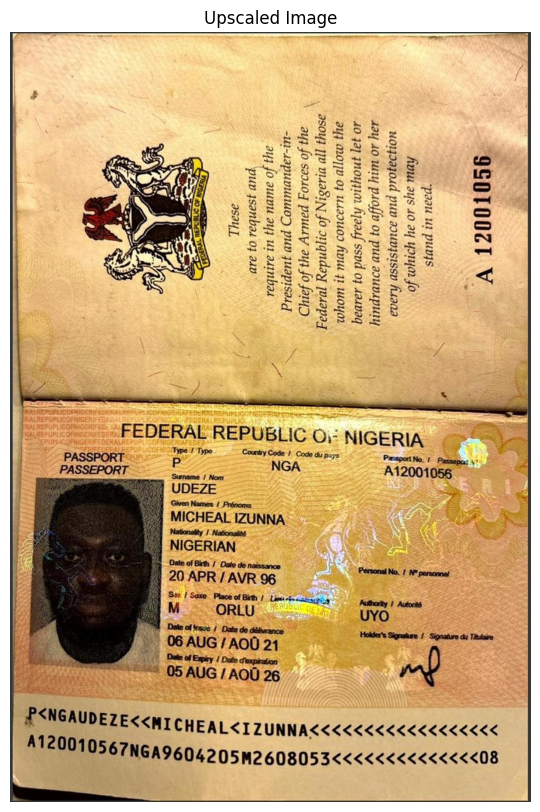

In [4]:
scale = 2.0
big = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
big_rgb = cv2.cvtColor(big, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.imshow(big_rgb)
plt.axis("off")
plt.title("Upscaled Image")
plt.show()


## make a helper to show cropped regions

In [5]:
def show_crop(image_bgr, x1, y1, x2, y2, title="crop"):
    crop = image_bgr[y1:y2, x1:x2]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 4))
    plt.imshow(crop_rgb)
    plt.axis("off")
    plt.title(title)
    plt.show()
    return crop

In [6]:
h, w = big.shape[:2]
print(h, w)

2560 1732


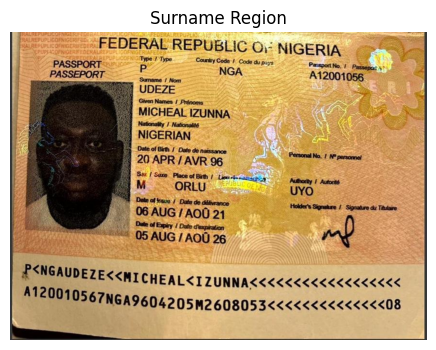

In [7]:
surname_crop = show_crop(big, 0, 1280, 1732, 2560 , "Surname Region")

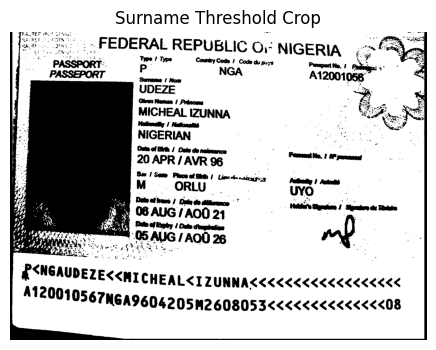

In [8]:
gray = cv2.cvtColor(surname_crop, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (3, 3), 0)
thr = cv2.threshold(gray, 140, 255, cv2.THRESH_BINARY)[1]

plt.figure(figsize=(10, 4))
plt.imshow(thr, cmap="gray")
plt.axis("off")
plt.title("Surname Threshold Crop")
plt.show()

In [9]:
config = r'--oem 3 --psm 6'
text = pytesseract.image_to_string(thr, lang="eng", config=config)
print(text)

ge). : . FEDERAL REPUBLIC Oy: NIGERIA ofS 2
_ "PASSPORT. = NGA A12001056°
PASSEPORT Suname | Nom * ope af
UDEZE Bs
= NIGERIAN ae
faa Oste of Bith / Date de neiseance _ Pegannal a. 1 8 parvomnel wo
BA OREN! Linens Riga | Ace
L MORLU UYO a.
ti “, ao | Qala de ditwence "= . tthe gaan / Siqnabon de Tinie
Yeh fae 06 AUG / AOO 21 : fn.
gh yf a
R<SNGAUDEZE<<py CHEAL<I ZUNNA<<<<<<<eKKcceceecccs
4120010567NGA9604205N2608053<<<<<<<<<<<<<<08



In [10]:
config = r'--oem 3 --psm 7'
text = pytesseract.image_to_string(thr, lang="eng", config=config)
print(text)


In [11]:
config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ '
text = pytesseract.image_to_string(thr, lang="eng", config=config)
print(text)

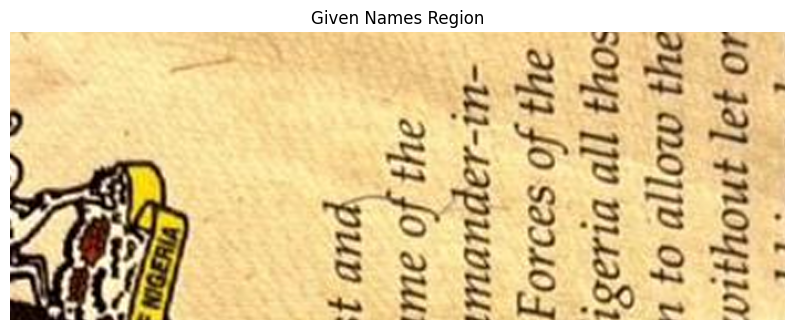

In [12]:
given_crop = show_crop(big, 500, 300, 1200, 560, "Given Names Region")

In [13]:
raw_text_gray   = pytesseract.image_to_string(gray_image, lang="deu+eng")
print(raw_text_gray)


NameError: name 'gray_image' is not defined

In [ ]:
contrast_enhancer = ImageEnhance.Contrast(gray_image)
contrast_image = contrast_enhancer.enhance(2.0) # try 1.5, 2.9, 2.5 if needed
contrast_enhancer

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(contrast_image,cmap="gray")
plt.axis("off")
plt.title("Contrast Enhanced Image")
plt.show()

In [ ]:
raw_text_contrast = pytesseract.image_to_string(contrast_image, lang="deu+eng")
print(raw_text_contrast)

In [ ]:
threshold_image = gray_image.point(lambda p: 255 if p > 100 else 0)
threshold_image

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(threshold_image, cmap="gray")
plt.axis("off")
plt.title("Threshold Image")
plt.show()

In [ ]:
raw_text_threshold = pytesseract.image_to_string(threshold_image, lang="deu+eng")
print(raw_text_threshold)

In [ ]:
print("=" * 80)
print("OCR FROM ORIGINAL")
print("=" * 80)
print(raw_text_original)



In [ ]:
print("\n" + "=" * 80)
print("OCR FROM GRAYSCALE")
print("=" * 80)
print(raw_text_gray)

In [ ]:


print("\n" + "=" * 80)
print("OCR FROM CONTRAST")
print("=" * 80)
print(raw_text_contrast)


In [ ]:

print("\n" + "=" * 80)
print("OCR FROM THRESHOLD")
print("=" * 80)
print(raw_text_threshold)

## save the best processed version
Suppose threshold image is best:

In [ ]:
output_dir = Path("test_docs/processed")
output_dir.mkdir(parents=True, exist_ok=True)

best_image_path = output_dir / f"{image_path.stem}_best.png"
threshold_image.save(best_image_path)

best_image_path